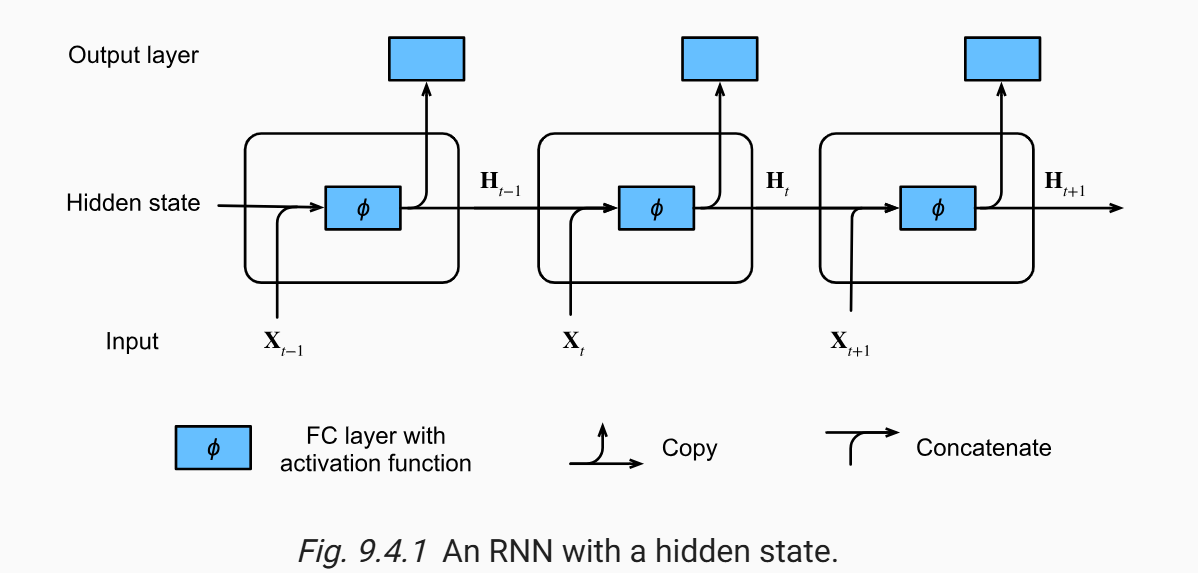

A RNN has hidden state.

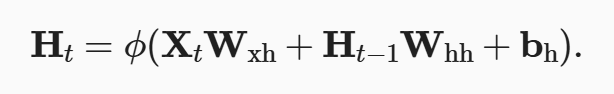

Hidden state at time step t is calculated using input at time step t and hidden state from previous time step t-1

Ht = g(Xt @ Wxh + Ht-1 @ Whh + bh) - The only additional term here if compared to MLP is the Ht-1 @ Whh multiplication. This term carries information from the previous terms in the sequence.

The output of the RNN is calculated as
Ot = Ht @ Whq + Bq

The parameters of the RNN are
* Wxh - d x h dimensional matrix
* Whh - h X h dimensional matrix
* bh - 1 x h vector
* Whq - h x q dimensional matrix
* bq - 1 x q vector

Xt @ Wxh + Ht-1 @ Whh expression when calculating Ht is implemented as a matrix multiplication by concatenating the matrices

Xt concat Ht-1 along columns - n x (d+h)
Wxh concat Whh along rows - (d+h) x h

In [57]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [58]:
#RNN Implementation from Scratch
class RNNScratch(d2l.Module): #@save
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W_xh = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

    def forward(self, inputs, state=None):
        if state is None:
            #Initialise state
            state = torch.zeros(inputs.shape[1], self.num_hiddens)
        else:
            state, = state
        outputs = []
        for X in inputs: #Share of inputs: (num_steps, batch_size, num_inputs)
            #print(f"{X.shape},{self.W_xh.shape},{self.W_hh.shape},{self.b_h.shape}")
            state = torch.tanh(torch.matmul(X, self.W_xh) + torch.matmul(state, self.W_hh) + self.b_h)
            outputs.append(state)
        return outputs, state

In [59]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

In [60]:
def check_len(a, n): #@save
    assert len(a) == n, f"list length {len(a)} != expected length {n}" 

def check_shape(a, shape): #@save
    assert a.shape == shape, f"tensor's shape {a.shape} != expected shape {shape}"

check_len(outputs, num_steps)
check_shape(outputs[0], (batch_size, num_hiddens))
check_shape(state, (batch_size, num_hiddens))

In [61]:
class RNNLMScratch(d2l.Classifier): #@save
    """The RNN based language model implemented from scratch"""
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.init_params()

    def init_params(self):
        self.W_hq = nn.Parameter(torch.rand(self.rnn.num_hiddens, self.vocab_size) * self.rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        return l
    
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

    def one_hot(self, X):
        #Output shape: (num_steps, batch_size, vocab_size)
        return F.one_hot(X.T, self.vocab_size).type(torch.float32)
    
    def output_layer(self, rnn_outputs):
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, 1)
    
    def forward(self, X, state=None):
        embs = self.one_hot(X)
        #print(embs.shape)
        rnn_outputs, _ = self.rnn(embs, state)
        return self.output_layer(rnn_outputs)
    
    def predict(self, prefix, num_preds, vocab, device=None):
        state, outputs = None, [vocab[prefix[0]]]
        for i in range(len(prefix) + num_preds - 1):
            X = torch.tensor([[outputs[-1]]], device=device)
            embs = self.one_hot(X)
            rnn_outputs, state = self.rnn(embs, state)
            if i < len(prefix) - 1:  # Warm-up period
                outputs.append(vocab[prefix[i + 1]])
            else:  # Predict num_preds steps
                Y = self.output_layer(rnn_outputs)
                outputs.append(int(Y.argmax(axis=2).reshape(1)))
        return ''.join([vocab.idx_to_token[i] for i in outputs])
        

In [62]:
model = RNNLMScratch(rnn, num_inputs)
output = model(torch.ones((batch_size, num_steps), dtype=torch.int64))
check_shape(output, (batch_size, num_steps, num_inputs))

In [63]:
#Gradient clipping
@d2l.add_to_class(d2l.Trainer) #@save
def clip_gradients(self, grad_clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > grad_clip_val:
        for params in params:
            params.grad[:] *= grad_clip_val / norm

In [64]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)

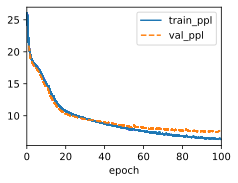

In [65]:

rnn = RNNScratch(num_inputs=len(data.vocab), num_hiddens=28)
model = RNNLMScratch(rnn, vocab_size=len(data.vocab), lr=1)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1)
trainer.fit(model, data)

In [66]:
model.predict('it has', 20, data.vocab)

'it has and the the time th'

In [67]:
#Concise Implementation
class RNN(d2l.Module): #@save
    def __init__(self, num_inputs, num_hiddens):
        super().__init__()
        self.save_hyperparameters()
        self.rnn = nn.RNN(num_inputs, num_hiddens)

    def forward(self, inputs, H=None):
        return self.rnn(inputs, H)

In [73]:
class RNNLM(d2l.RNNLMScratch): #@save
    def init_params(self):
        self.linear = nn.LazyLinear(self.vocab_size)

    def output_layer(self, hiddens):
        return self.linear(hiddens).swapaxes(0,1)

In [74]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNN(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
model.predict('it has', 20, data.vocab)

'it haszkupkkbkpkbkpkbkpkbk'

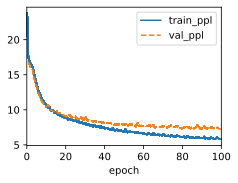

In [75]:
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [76]:
model.predict('it has', 20, data.vocab)

'it has and the pare the pa'